In [13]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import Divider, Size
from itertools import product
from string import ascii_lowercase
from matplotlib.lines import Line2D
from pathlib import Path
from IPython.display import display, clear_output


In [14]:
BATCH = "008"
# Use .expanduser() to turn "~" into "/home/yourusername"
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/histograms").expanduser()


In [15]:
sarafu = pickle.load(open(SARAFU_PICKLED / "sarafu.pkl", "rb"))
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))


In [16]:
ss = metadata.s.unique() 
bb = metadata.burstiness.unique()



In [17]:
mpl.rcdefaults()
N=10
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24) 


# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.5, 0.6         # margins in inches
bottom, top = 1.2, 0.6            # margins in inches

fig_w = ax_w + left + right
fig_h = ax_h + bottom + top



In [ ]:

for spending_noise, burstiness in product(ss, bb):
    QUERY = f"s == {spending_noise} and burstiness == {burstiness}"
    meta_row = metadata.query(QUERY).iloc[0]
    simu_id = meta_row.simulation_id

    # keywords
    kw_fb = "final_balances"
    kw_ts = "transaction_size"

    disp = 'overlap'

    keyword = kw_fb + "+"+ kw_ts

    # filenames (standard)
    fname_fb_sarafu = f"sarafu__metric={kw_fb}__s=NA__b=NA"
    fname_fb_simu   = f"simulation__metric={kw_fb}__s={spending_noise}__b={burstiness}"

    fname_ts_sarafu = f"sarafu__metric={kw_ts}__s=NA__b=NA"
    fname_ts_simu   = f"simulation__metric={kw_ts}__s={spending_noise}__b={burstiness}"

    save_name=f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"

    # load histograms
    h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_fb_sarafu}.pkl", "rb"))
    h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_fb_simu}.pkl", "rb"))

    h3 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_ts_sarafu}.pkl", "rb"))
    h4 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_ts_simu}.pkl", "rb"))

    fig = plt.figure(figsize=(fig_w, fig_h))

    divider = Divider(
        fig, (0, 0, 1, 1),
        horizontal=[
            Size.Fixed(left),
            Size.Fixed(ax_w),
            Size.Fixed(right),
        ],
        vertical=[
            Size.Fixed(bottom),
            Size.Fixed(ax_h),
            Size.Fixed(top),
        ],
    )

    ax = fig.add_axes(
        divider.get_position(),
        axes_locator=divider.new_locator(nx=1, ny=1)
    )

    ax.plot(h1[0], h1[1], "--", color="tab:blue")
    ax.plot(h2[0], h2[1], "o",  color="tab:blue")

    ax.plot(h3[0], h3[1], "--", color="tab:orange")
    ax.plot(h4[0], h4[1], "o",  color="tab:orange")

    ax.set_xlabel("$x = w, m$")
    ax.set_ylabel("$P(x)$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    # ax.text(0.05,0.1,f'(a)' if spending_noise==ss[0] else f'(b)',transform=ax.transAxes, va="top", fontsize=N+24)

    # label_model=rf"Model: $\xi={s}, b={b}$"
    label_model=rf"Model"

    # custom legend

    legend_elements = [
        Line2D([0], [0], linestyle="--", color="black", label="Sarafu"),
        Line2D([0], [0], linestyle="None", marker="o", color="black",
            label=label_model),
        # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
        # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
    ]

    ax.legend(handles=legend_elements)
    # print(save_name)
    save=1
    if save:
        fig.savefig(
            FIGURES / f"{save_name}",
            format='pdf',
        )
        plt.close()

In [26]:

bb = [0.75, 1.0]
ss = [1,250]

for spending_noise, burstiness in product(ss, bb):
    QUERY = f"s == {spending_noise} and burstiness == {burstiness}"
    meta_row = metadata.query(QUERY).iloc[0]
    simu_id = meta_row.simulation_id

    # keywords
    kw_fb = "final_balances"
    kw_ts = "transaction_size"

    disp = 'overlap'

    keyword = kw_fb + "+"+ kw_ts

    # filenames (standard)
    fname_fb_sarafu = f"sarafu__metric={kw_fb}__s=NA__b=NA"
    fname_fb_simu   = f"simulation__metric={kw_fb}__s={spending_noise}__b={burstiness}"

    fname_ts_sarafu = f"sarafu__metric={kw_ts}__s=NA__b=NA"
    fname_ts_simu   = f"simulation__metric={kw_ts}__s={spending_noise}__b={burstiness}"

    save_name=f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"

    # load histograms
    h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_fb_sarafu}.pkl", "rb"))
    h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_fb_simu}.pkl", "rb"))

    h3 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_ts_sarafu}.pkl", "rb"))
    h4 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_ts_simu}.pkl", "rb"))

    fig = plt.figure(figsize=(fig_w, fig_h))

    divider = Divider(
        fig, (0, 0, 1, 1),
        horizontal=[
            Size.Fixed(left),
            Size.Fixed(ax_w),
            Size.Fixed(right),
        ],
        vertical=[
            Size.Fixed(bottom),
            Size.Fixed(ax_h),
            Size.Fixed(top),
        ],
    )

    ax = fig.add_axes(
        divider.get_position(),
        axes_locator=divider.new_locator(nx=1, ny=1)
    )

    ax.plot(h1[0], h1[1], "--", color="tab:blue")
    ax.plot(h2[0], h2[1], "o",  color="tab:blue")

    ax.plot(h3[0], h3[1], "--", color="tab:orange")
    ax.plot(h4[0], h4[1], "o",  color="tab:orange")

    ax.set_xlabel("$x = w, m$")
    ax.set_ylabel("$P(x)$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    # ax.text(0.05,0.1,f'(a)' if spending_noise==ss[0] else f'(b)',transform=ax.transAxes, va="top", fontsize=N+24)

    # label_model=rf"Model: $\xi={s}, b={b}$"
    label_model=rf"Model"

    # custom legend
    if spending_noise == 1:
        legend_elements = [
            Line2D([0], [0], linestyle="--", color="black", label="Sarafu"),
            Line2D([0], [0], linestyle="None", marker="o", color="black",
                label=label_model),
            # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
            # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
        ]

        ax.legend(handles=legend_elements, loc= 'lower left')
    if burstiness == 1.0:        
        ax.text(0.9,0.95,f'(a)' if spending_noise==1 else f'(b)',transform=ax.transAxes, va="top", fontsize=N+24)
    # print(save_name)
    save=1
    if save:
        fig.savefig(
            FIGURES / f"{save_name}",
            format='pdf',
        )
        plt.close()

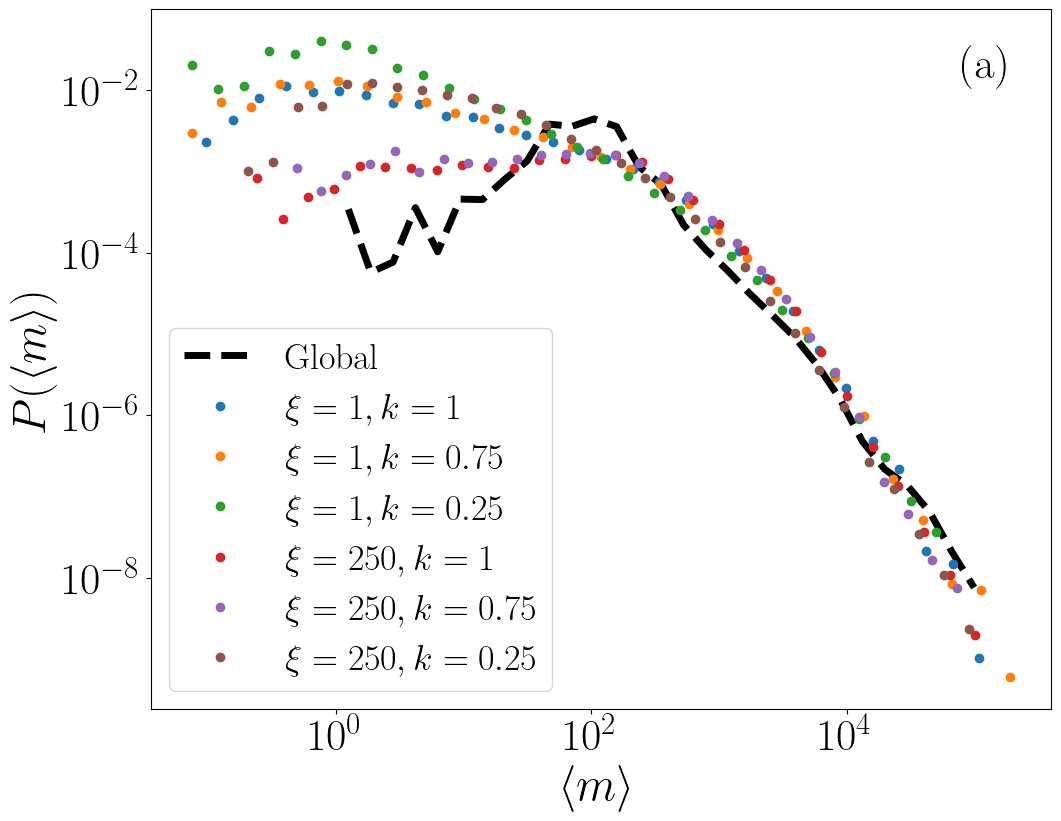

In [11]:
bb = [1,0.75,0.25]
ss = [1,250]


keyword = 'average_balances'
disp = 'single'
tag = f"s={ss}__b={bb}"
x_text = 0.9
y_text = 0.95
xlabel = r"$\langle m \rangle$"
ylabel = r"$P(\langle m \rangle)$"

save_name = f"{disp}__metric={keyword}__filter={tag}.pdf"

loglog = True

fname_sarafu = "sarafu__metric=average_balances__s=NA__b=NA.pkl"
fname_simu = "simulation__metric=average_balances_20_periods.pkl"
h0 = pickle.load(open(SARAFU_PICKLED/'histograms'/f"{fname_sarafu}","rb"))
hs = pickle.load(open(PICKLED/BATCH/'histograms'/f"{fname_simu}",'rb'))

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)
ax.plot(h0[0], h0[1], "--", color="k",lw = 5,label = "Global")

for spending_noise, burstiness in product(ss, bb):
    QUERY = f"s == {spending_noise} and burstiness == {burstiness}"
    meta_row = metadata.query(QUERY).iloc[0]
    simu_id = meta_row.simulation_id

    h = hs[spending_noise][burstiness]

    ax.plot(h[0],h[1],ls='',marker='o', label = fr"$\xi={spending_noise},k={burstiness}$")

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

ax.legend(fontsize = 26)
ax.text(0.9,0.95, "(a)", transform=ax.transAxes, va="top")
# fig.savefig("buff2.pdf")
fig.savefig(FIGURES /f'{save_name}')


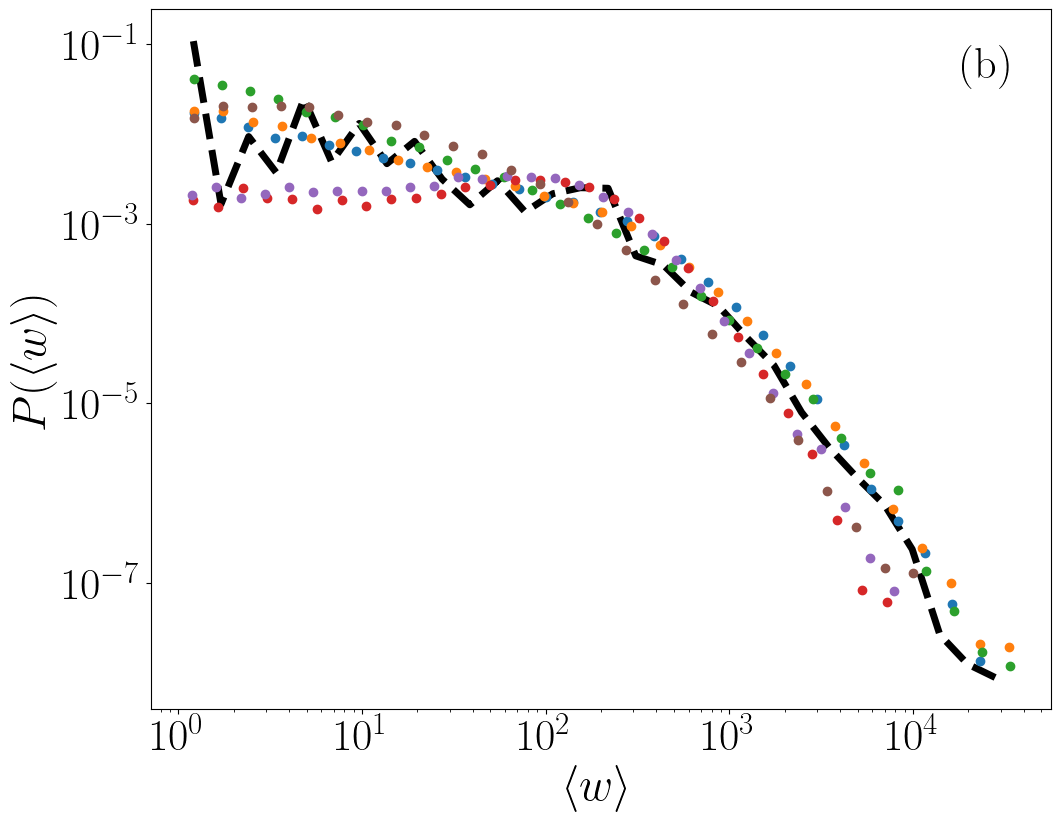

In [12]:
bb = [1,0.75,0.25]
ss = [1,250]


keyword = 'average_transactions'
disp = 'single'
tag = f"s={ss}__b={bb}"
x_text = 0.9
y_text = 0.95
xlabel = r"$\langle w \rangle$"
ylabel = r"$P(\langle w \rangle)$"

save_name = f"{disp}__metric={keyword}__filter={tag}.pdf"

loglog = True

fname_sarafu = "sarafu__metric=average_transactions__s=NA__b=NA.pkl"
fname_simu = "simulation__metric=average_transactions_20_periods.pkl"
h0 = pickle.load(open(SARAFU_PICKLED/'histograms'/f"{fname_sarafu}","rb"))
hs = pickle.load(open(PICKLED/BATCH/'histograms'/f"{fname_simu}",'rb'))

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)
ax.plot(h0[0], h0[1], "--", color="k",lw = 5,label = "Global")

for spending_noise, burstiness in product(ss, bb):
    QUERY = f"s == {spending_noise} and burstiness == {burstiness}"
    meta_row = metadata.query(QUERY).iloc[0]
    simu_id = meta_row.simulation_id

    h = hs[spending_noise][burstiness]

    ax.plot(h[0],h[1],ls='',marker='o', label = fr"$\xi={spending_noise},k={burstiness}$")

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

# ax.legend(fontsize = 22)
ax.text(0.9,0.95, "(b)", transform=ax.transAxes, va="top")
# fig.savefig("buff2.pdf")
fig.savefig(FIGURES /f'{save_name}')
